# Bayesian uncertainty quantification Jupyter notebook

In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt
import scipy
import pandas as pd


#plt.rcParams['figure.figsize']=(14.4,7.4)
#Some pretty colors I like
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [ ]:
# reading the oslo data for 300 bin (6,9)

df=pd.read_csv("ld_300(6,9).csv")

#df_new = df.copy()
df_new = df[df['energy'] >=1]  # talys_ld starts from 1.25

# convert to python arrays
energy=df_new["energy"].values # as numpy array
ld=df_new["ld"].values
error=df_new["errors"].values

print(energy)
print(ld)
print(error)


energy=np.append(energy,5.56)
ld =np.append(ld,821)
error = np.append(error,189)


energy = energy[3:]
ld =ld[3:]
error = error[3:]

print(energy)
print(ld)
print(error)

[1.041 1.341 1.641 1.941 2.241 2.541 2.841 3.141 3.441 3.741 4.041 4.341
 4.641 4.941 5.241]
[  4.3981805   7.9218979   5.7775831   5.332778   13.171192   18.622341
  30.102291   34.471684   98.746201   74.986275  132.87492   185.18456
 169.01286   348.42517   447.9805   ]
[  1.2988422   2.2828012   2.0766733   2.2662923   4.6543274   7.2097344
  10.852059   16.361855   36.145912   37.800491   65.006676  110.82074
 119.84811   214.01866   320.42114  ]
[1.941 2.241 2.541 2.841 3.141 3.441 3.741 4.041 4.341 4.641 4.941 5.241
 5.56 ]
[  5.332778  13.171192  18.622341  30.102291  34.471684  98.746201
  74.986275 132.87492  185.18456  169.01286  348.42517  447.9805
 821.      ]
[  2.2662923   4.6543274   7.2097344  10.852059   16.361855   36.145912
  37.800491   65.006676  110.82074   119.84811   214.01866   320.42114
 189.       ]


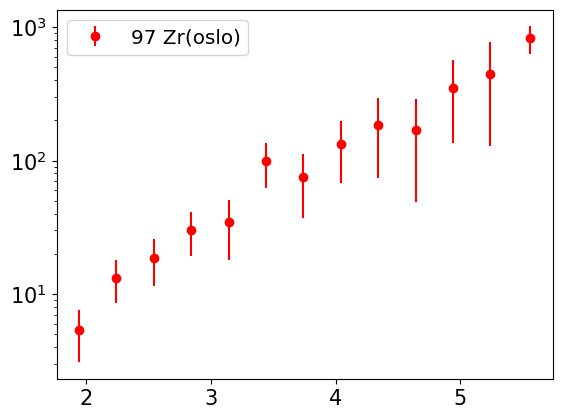

In [ ]:
# Plot the oslo data with error bars

fig = plt.figure()


plt.errorbar(energy, ld,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')

plt.yscale("log")



plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

<font size="5">
The model we will use to fit to this data set is:
    
    

model 5

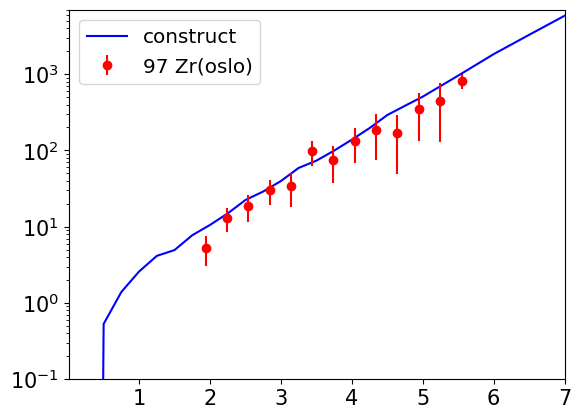

,Ex,total,JP=0.5,JP=1.5,JP=2.5,JP=3.5,JP=4.5,JP=5.5,JP=6.5,JP=7.5,JP=8.5
0,0.00,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30,1.000000e-30
1,0.05,5.180000e-01,1.070000e-02,2.000000e-01,6.160000e-02,6.160000e-02,6.160000e-02,6.160000e-02,6.160000e-02,1.000000e-30,1.000000e-30
3,0.10,1.036000e+00,2.140000e-02,4.000000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.000000e-30,1.000000e-30
4,0.10,1.036000e+00,2.140000e-02,4.000000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.232000e-01,1.000000e-30,1.000000e-30
5,0.15,1.554000e+00,3.210000e-02,6.000000e-01,1.848000e-01,1.848000e-01,1.848000e-01,1.848000e-01,1.848000e-01,1.000000e-30,1.000000e-30
...,...,...,...,...,...,...,...,...,...,...,...
591,199.80,3.117000e+32,2.059000e+30,4.108000e+30,6.129000e+30,8.114000e+30,1.002000e+31,1.187000e+31,1.372000e+31,1.428000e+31,1.512000e+31
592,199.85,3.147000e+32,2.079000e+30,4.148000e+30,6.189000e+30,8.192000e+30,1.011000e+31,1.198000e+31,1.386000e+31,1.442000e+31,1.526000e+31
593,199.90,3.178000e+32,2.099000e+30,4.188000e+30,6.248000e+30,8.271000e+30,1.021000e+31,1.210000e+31,1.399000e+31,1.456000e+31,1.541000e+31
594,199.95,3.209000e+32,2.119000e+30,4.228000e+30,6.308000e+30,8.351000e+30,1.031000e+31,1.222000e+31,1.412000e+31,1.470000e+31,1.556000e+31


In [ ]:
# contruct from the database
# just to see that construction works , nothing else
# construct
# this is only used for pulling down values

# interpo;ation always happens from the master set !!!!!!!!!

df_p =pd.read_pickle("master_base_ld_p.pkl")
df_n = pd.read_pickle("master_base_ld_n.pkl")


df_base_p =pd.read_pickle("base_ld_p.pkl")
df_base_n = pd.read_pickle("base_ld_n.pkl")

# fresh can be used for anything
df_param_p = df_base_p.copy()
df_param_n = df_base_n.copy()


ctable = -0.08
ptable = 0.4

new_energy = df_base_p['Ex'].values - ptable

# for postive_ld
for col in df_base_p.columns[1:]:
    shifted_values = np.interp(new_energy, df_p['Ex'].values, df_p[col].values)
    new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
    df_base_p[col] = new_values

new_energy = df_base_n['Ex'].values - ptable

# for negative_ld
for col in df_base_n.columns[1:]:
    shifted_values = np.interp(new_energy, df_n['Ex'].values, df_n[col].values)
    new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
    df_base_n[col] = new_values


df_final= df_base_p.set_index('Ex').add(df_base_n.set_index('Ex'), fill_value=0).reset_index()

df_final['ld_eff']=df_final['JP=0.5']+df_final['JP=1.5']+df_final['JP=2.5']

#df_final=df_final[df_final['Ex']>0.25]

#df_final=df_final[df_final['Ex']<8]
df_final['ld_eff']





plt.plot(df_final['Ex'], df_final['ld_eff'],color='b', label = 'construct')
plt.errorbar(energy, ld,yerr=error,fmt="o", color="r",ecolor='r',label='97 Zr(oslo)')

plt.yscale("log")

plt.xlim(0.005,7)
plt.ylim(0.1,7000)

plt.legend(loc ='upper left',fontsize="x-large")
plt.show()


df_p

<font size="5">
Linear interpolation

In [ ]:
#linear interpolation for the talys values on energy/x in the oslo data
# needed for the likelihood function


#intp_ld = np.interp(energy, energy_t, ld_t)



In [ ]:
'''
#verification whether the interpolation did its job!!! interpolated data vs model

fig = plt.figure()


plt.plot(energy_t,ld_t,label='gsf from talys ')

plt.scatter(energy,intp_ld,label='interpolated_gsf',color='r')

plt.yscale("log")


plt.legend(loc ='upper left',fontsize="x-large")
plt.show()


print(intp_ld.size)'''

'\n#verification whether the interpolation did its job!!! interpolated data vs model\n\nfig = plt.figure()\n\n\nplt.plot(energy_t,ld_t,label=\'gsf from talys \')\n\nplt.scatter(energy,intp_ld,label=\'interpolated_gsf\',color=\'r\')\n\nplt.yscale("log")\n\n\nplt.legend(loc =\'upper left\',fontsize="x-large")\nplt.show()\n\n\nprint(intp_ld.size)'

Bayesian starts here

In [ ]:
def model_all(params):
    df1 = df_param_p.copy()
    df2 = df_param_n.copy()

    ctable_vis= -0.08
    ptable_vis= 0.4

    ctable = params[0]+ctable_vis
    ptable = params[1]+ptable_vis


    new_energy = df1['Ex'].values - ptable

    # for postive_ld
    for col in df1.columns[1:]:
        shifted_values = np.interp(new_energy, df_p['Ex'].values, df_p[col].values)
        new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
        df1[col] = new_values

    new_energy = df2['Ex'].values - ptable

    # for negative_ld
    for col in df2.columns[1:]:
        shifted_values = np.interp(new_energy, df_n['Ex'].values, df_n[col].values)
        new_values = np.exp(ctable* np.sqrt(np.abs(new_energy)))* shifted_values
        df2[col] = new_values


    df_end= df1.set_index('Ex').add(df2.set_index('Ex'), fill_value=0).reset_index()

    df_end['ld_eff']=df_end['JP=0.5']+df_end['JP=1.5']+df_end['JP=2.5']

    #df_final=df_final[df_final['Ex

    ld_eff_np=  df_end['ld_eff'].values

    return ld_eff_np


In [ ]:
'''
for i, col in enumerate(df_p.columns[2:5]):
    print(col, "hello", i)



shifted_values = np.zeros((3))
print(shifted_values[2])'''

'\nfor i, col in enumerate(df_p.columns[2:5]):\n    print(col, "hello", i)\n\n\n\nshifted_values = np.zeros((3))\nprint(shifted_values[2])'

In [ ]:
def model_ld5(j,params):

    ctable_vis= -0.08
    ptable_vis= 0.4

    ctable = params[0]+ctable_vis
    ptable = params[1]+ptable_vis


    new_energy = energy[j] - ptable

    # for positives
    shifted_values = np.zeros((3))

    for i, col in enumerate(df_p.columns[2:5]):
        temp = np.interp(new_energy, df_p['Ex'].values, df_p[col].values)
        shifted_values[i] =  np.exp(ctable* np.sqrt(np.abs(new_energy)))* temp

    pos_values = np.sum(shifted_values)

    # for positives
    shifted_values = np.zeros((3))

    for i, col in enumerate(df_n.columns[2:5]):
        temp = np.interp(new_energy, df_n['Ex'].values, df_n[col].values)
        shifted_values[i] =  np.exp(ctable* np.sqrt(np.abs(new_energy)))* temp

    neg_values = np.sum(shifted_values)


    # adding both
    ld_ef = neg_values+pos_values


    return ld_ef



In [ ]:
# Define the likelihood function for given errors sigma
def likelihood(params,arguments):
#Assumed format for data=[xvals,yvals]
    data, model, sigmas = arguments
    likelihood_log_val=0

    for i in range(len(data[0])):
        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model_ld5(i,params)) / sigmas[i])**2\
        -np.log(2*np.pi*sigmas[i]**2)/2


    return np.exp(likelihood_log_val)

def prior_model_ld5(params_vals,arguments):
    params0,params0_Cov_Inv_matrix=arguments

    if params_vals[1]> 1.491:             # this condition so that energy never becomes negative
        return 0
    else:
        mu=np.array(params_vals)-np.array(params0)
        params_size=len(params_vals)
        return (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)



In [ ]:
# Define the Metropolis algorithm
def metropolis(data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
#     step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    #thermalizing
    burn_samples=1000
    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]

    acceptance_times=0

    cov_step_size=np.diag(step_size)**2

    posterior_current=(likelihood(params_current,likelihood_arguments))*(prior(params_current,\
                                                                               prior_arguments))

    # Run the Metropolis-Hastings algorithm for burning
    for i in range(burn_samples):
        # Propose a new state for the chain
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)

        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*(prior(params_proposed,\
                                                                               prior_arguments))

        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)

        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*\
        (prior(params_proposed,prior_arguments))

        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1

        # Store the current state
        params_list.append(params_current)
        posterior_list.append(posterior_current)


    #Rule of thumb acceptance is around 50%.
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see.
    print(acceptance_times/num_iterations*100,"%")

    return(np.array(params_list),np.array(posterior_list),\
           acceptance_times/num_iterations*100)




Running Full MCMC setup

In [ ]:

#Setting up the prior
#prior_arguments_A=[[0,0],np.linalg.inv(np.diag([2**2,2**2]))]

#prior_arguments_A=[[-0.303,-0.303],np.linalg.inv(np.diag([44,44]))]


# for startiing from 2 MEV case
#prior_arguments_A=[[0.0603,0.36],np.linalg.inv(np.diag([2**2,2**2]))]

#prior_arguments_A=[[0.0603,0.36],np.linalg.inv(np.diag([5**2,5**2]))]


prior_arguments_A=[[0.0,0.0],np.linalg.inv(np.diag([5**2,5**2]))]


#Doing the Metropolis sampling for 100000 values
results_A=metropolis([energy,ld],error, prior_model_ld5,\
                         prior_arguments_A, likelihood,model_ld5,100000, [0.1,0.1])
all_chains =results_A[0]

print(all_chains)

51.315999999999995 %
[[-0.12651552 -0.11093342]
 [-0.12651552 -0.11093342]
 [-0.11377587 -0.02669723]
 ...
 [ 0.52866587  0.9387765 ]
 [ 0.52866587  0.9387765 ]
 [ 0.52866587  0.9387765 ]]


 Drawing different chains in MCMC

Lets plot the parameters we visited from the Metropolis algorithm using the corner package in python

(100000,)


(0.0, 100000.0)

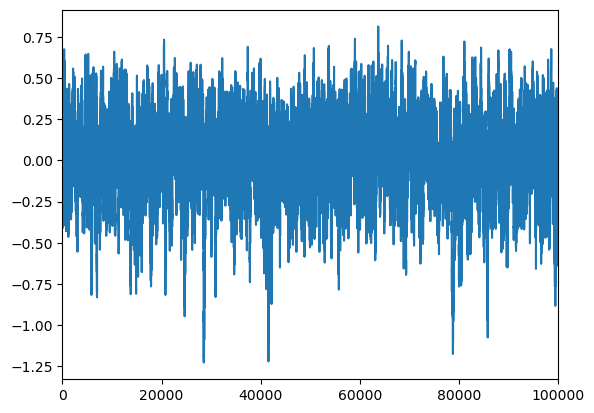

In [ ]:
b =np.arange((100000))
b=b+1
print(b.shape)

plt.plot(b,all_chains[:,0])
#plt.plot(b,all_chains[:,1], color ='r')
plt.xlim(0,100000)

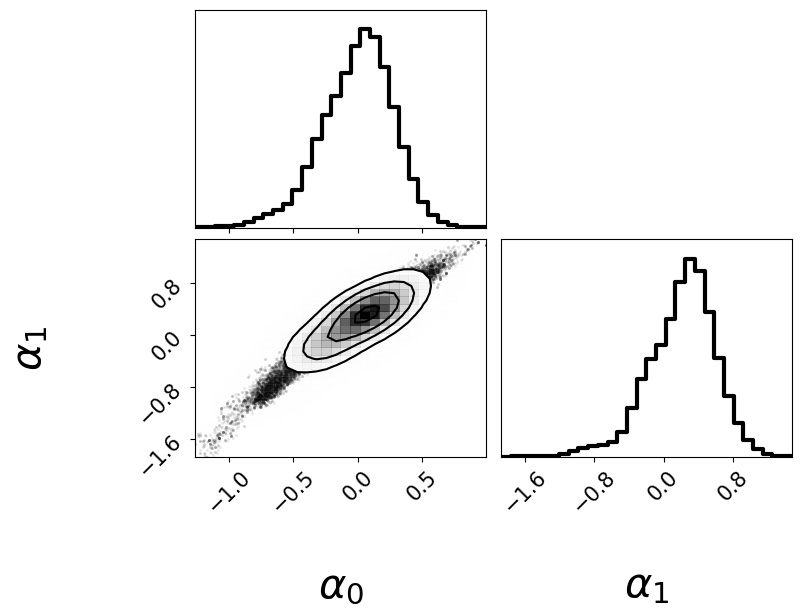

In [ ]:

figure = corner.corner(all_chains,
    labels=[r'$\alpha_0$',r'$\alpha_1$'],
    labelpad=0.2,
                       bins=30,
    label_kwargs={"fontsize":30},
                      hist_kwargs= {"linewidth":3},
    quantiles=None
#                        ,truths=[0,1], truth_color='r'
                       ,
    smooth=(1.7)
                       ,
    smooth1d=1.0
                      )


width = 8
height = 6
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)


plt.savefig(r"contour_plot_ld.jpg", format='jpg', dpi=300, bbox_inches='tight')

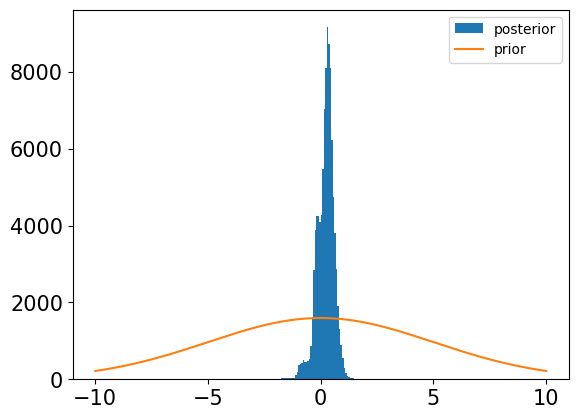

In [ ]:
plt.hist(all_chains[:,1], bins=50, label ='posterior')

mu = 0.0    # center
sigma = 5     # standard deviation

x = np.linspace(mu - 2*sigma, mu + 2*sigma, 500)

y = 20000*(1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.plot(x, y,label='prior')

plt.legend()
#plt.plot(x, norm.pdf(x, mu, sigma))
plt.show()

In [ ]:
#Taking 10000 samples from the visited posterior to estimate the percentiles in the model predictions

rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(10000),replace=False)

print(alpha_rand)


[[-0.18725587 -0.01856111]
 [ 0.13355381  0.33305542]
 [ 0.34959355  0.49031968]
 ...
 [ 0.00674778  0.34201422]
 [ 0.05729861  0.16890497]
 [-0.00874362  0.18921761]]


In [ ]:
rng2 = np.random.default_rng()
alpha_rand2 = rng2.choice(all_chains,(150),replace=False)

#np.savetxt('file1.txt', alpha_rand2, fmt='%.6f')
print(alpha_rand2)

[[ 0.05462028  0.35967209]
 [-0.14271317 -0.03222822]
 [ 0.34158524  0.84034862]
 [ 0.23875506  0.50501474]
 [ 0.17982254  0.39870555]
 [ 0.19077466  0.42040274]
 [ 0.45856183  0.75127935]
 [-0.0448811   0.28260591]
 [ 0.0644083   0.37010597]
 [ 0.25301807  0.64319213]
 [-0.43824092 -0.51906652]
 [-0.05332211  0.07297946]
 [ 0.08532088  0.33397615]
 [ 0.23339666  0.59569212]
 [-0.05029268  0.12596899]
 [ 0.01618639  0.24083336]
 [ 0.15365977  0.48183474]
 [ 0.09644898  0.35098855]
 [ 0.32069448  0.73954331]
 [-0.3294851  -0.14220375]
 [ 0.07021018  0.32354369]
 [ 0.09259475  0.31662509]
 [-0.04938813  0.2141423 ]
 [-0.35654058 -0.23484743]
 [-0.06847375  0.17356159]
 [-0.30335388 -0.14912775]
 [ 0.05660851  0.38472755]
 [ 0.1182604   0.39941025]
 [ 0.17044347  0.40035481]
 [ 0.09063226  0.31277636]
 [ 0.01323704  0.24821968]
 [ 0.38709917  0.72941645]
 [ 0.02402273  0.40001685]
 [-0.31250217 -0.29777968]
 [-0.14219796  0.03942535]
 [-0.14183297 -0.17505457]
 [-0.69594237 -0.83721004]
 

In [ ]:
np.random.seed(142857)
func_rand=[model_all(alpha) for alpha in alpha_rand]

In [ ]:
#ld model 5 positive parity

df1_init=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\talys\\what is talys actually doing to gsf\\new_best_talys for 97Zr\\ld_p.txt",delimiter=r"\s+")
df1_init['ld_eff']=df1_init['JP=0.5']+df1_init['JP=1.5']+df1_init['JP=2.5']
df1_init=df1_init[df1_init['Ex']<8]

df2_init=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\talys\\what is talys actually doing to gsf\\new_best_talys for 97Zr\\ld_n.txt",delimiter=r"\s+")
df2_init['ld_eff']=df2_init['JP=0.5']+df2_init['JP=1.5']+df2_init['JP=2.5']
df2_init=df2_init[df2_init['Ex']<8]

df_init = df1_init.set_index('Ex').add(df2_init.set_index('Ex'), fill_value=0).reset_index()
df_init=df_init[df_init['Ex']>0.25]



Lets make a plot of the predictions of our calibrated model

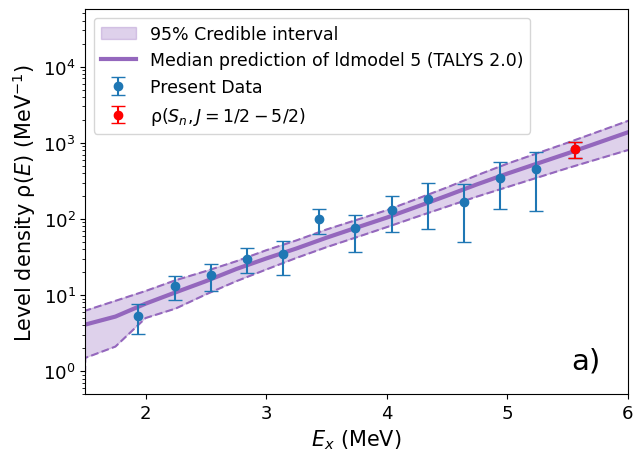

(60,)
(60,)


In [ ]:

df_init2= df_init.copy()


fig, ax = plt.subplots(figsize=(7,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))

energy_t =df_param_p['Ex'].values
ax.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.3,label='95% Credible interval')


ax.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median prediction of ldmodel 5 (TALYS 2.0)')
ax.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
ax.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')

#df_init2['ld_eff'] = df_init2['ld_eff']*0.80

#ax.plot(df_init2['Ex'], df_init2['ld_eff'], color='black', label = 'Initial fit of ldmodel 5')

#If you want to see the true function that generated these, uncomment the following line
# ax.plot(x_func, true_function_A(x_func), label='True Function',color='r', alpha=0.6)

#ax.plot(energy_t, func_rand[5088], color='yellow',linestyle='dashed')

ax.errorbar(energy, ld, yerr=error, fmt='o', capsize=5,label='Present Data')

ax.errorbar(5.56, 821, yerr=189, fmt='o', capsize=5, color='r',label=r'$\mathrm{\rho}(S_n ,J = 1/2- 5/2)$')


plt.legend(fontsize=15,frameon=True, edgecolor='black')



plt.yscale("log")


plt.xlim(1.5,6)
plt.ylim(0.5,57000)
#plt.xlim(1, 6)


ax.set_xlabel(r'$E_{x}$ (MeV)',fontsize=15)
ax.set_ylabel(r"Level density $\mathrm{\rho}(E)$ (MeV$^{-1}$)",fontsize=15)

#plt.rc('xtick', labelsize=13)
#plt.rc('ytick', labelsize=13)


plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)


plt.legend(loc ='upper left', fontsize=12.5)


ax.text(0.95, 0.05, 'a)', transform=ax.transAxes,
        fontsize=21, va='bottom', ha='right')

plt.savefig(r"bayesian_ld.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


print(upper.shape)

print(lower.shape)

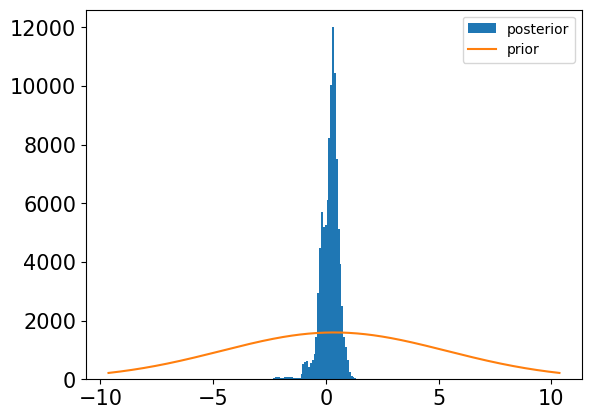

In [ ]:
plt.hist(all_chains[:,1], bins=50, label ='posterior')

mu = 0.36     # center
sigma = 5     # standard deviation

x = np.linspace(mu - 2*sigma, mu + 2*sigma, 500)

y = 20000*(1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

plt.plot(x, y,label='prior')

plt.legend()
#plt.plot(x, norm.pdf(x, mu, sigma))
plt.show()

What if we want to predict the value of f at a specific location? For example x=3

Finally, what if we are interested in the predictive distribution of new observations? We need to fold in the noise we expect to observe into our calculations.

See Eq. 30 and Sec 4 in: https://www.frontiersin.org/articles/10.3389/fphy.2022.1054524/full

Fantastic! Now you can tackle the other 7 problems :)